In [1]:
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

iris_df=pd.read_csv("Iris.csv")
iris_df.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [2]:
iris_df.isnull().any()

sepal.length    False
sepal.width     False
petal.length    False
petal.width     False
variety         False
dtype: bool

In [3]:
iris_df.dtypesimport numpy as np


sepal.length    float64
sepal.width     float64
petal.length    float64
petal.width     float64
variety          object
dtype: object

In [4]:
iris_df.describe()

,sepal.length,sepal.width,petal.length,petal.width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


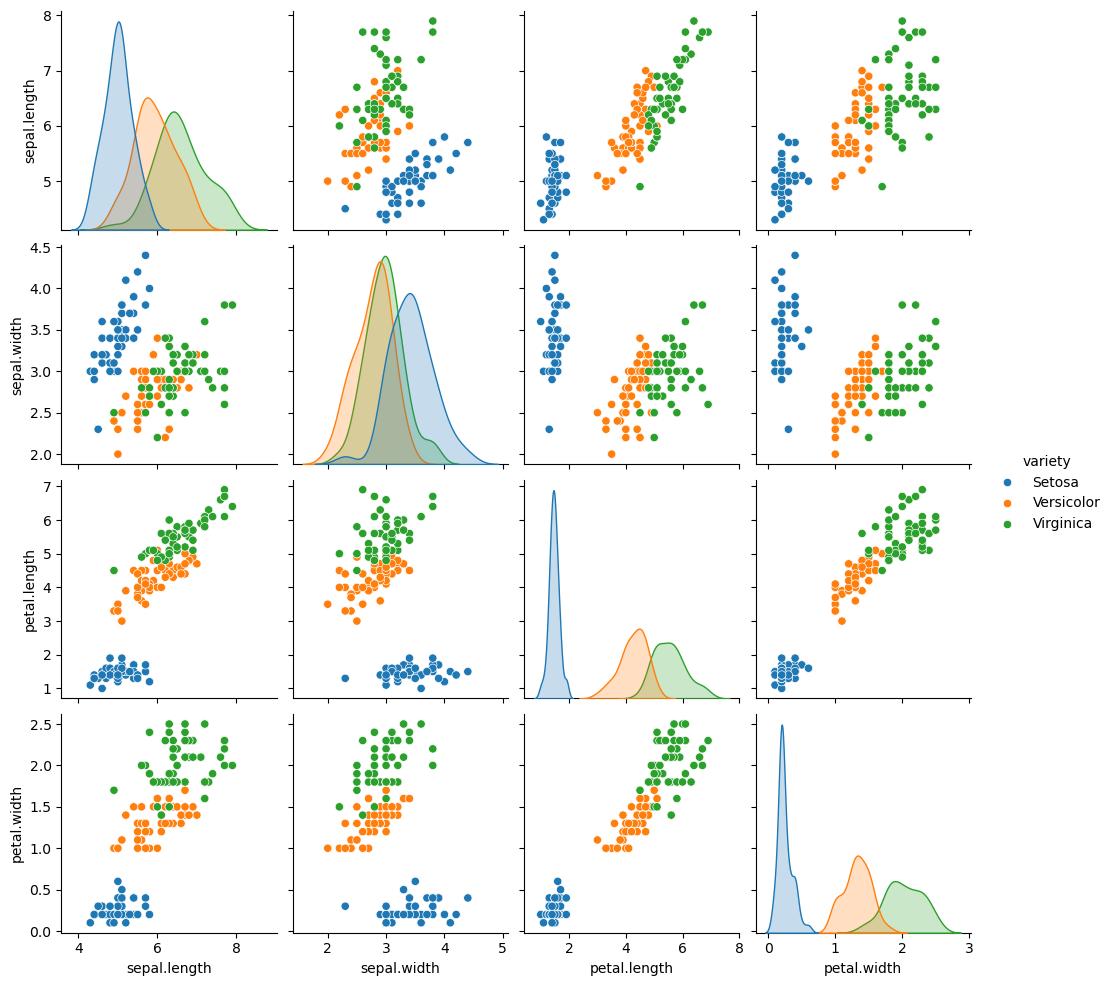

In [6]:
sns.pairplot(iris_df,hue='variety')
plt.savefig("exercise2a.png")
plt.show()

In [9]:
X=iris_df[['sepal.length','sepal.width','petal.length','petal.width']].values
y=iris_df['variety'].values
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.9,random_state=1)
clf=tree.DecisionTreeClassifier()
clf=clf.fit(X_train,y_train)
prediction=clf.predict(X_test)
prediction

array(['Setosa', 'Versicolor', 'Versicolor', 'Setosa', 'Virginica',
       'Versicolor', 'Virginica', 'Setosa', 'Setosa', 'Virginica',
       'Versicolor', 'Setosa', 'Virginica', 'Versicolor', 'Versicolor'],
      dtype=object)

In [10]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00         5
  Versicolor       1.00      1.00      1.00         6
   Virginica       1.00      1.00      1.00         4

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



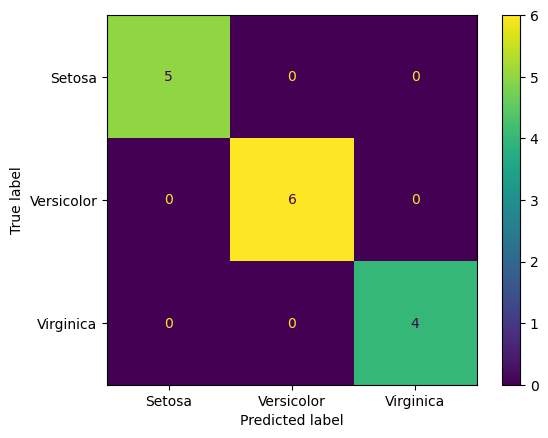

In [11]:
ConfusionMatrixDisplay.from_estimator(clf,X_test,y_test)
plt.savefig("exercise2b.png")
plt.show()

In [13]:
!pip install pydotplus --break-system-packages
!pip install graphviz --break-system-packages

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.7/278.7 kB 6.9 MB/s eta 0:00:00 MB/s eta 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for pydotplus: filename=pydotplus-2.0.2-py3-none-any.whl size=24552 sha256=650cffb82c8b8ce50f0b528ea88ec70f1819aab3e3d05d4d0627138a4c49467d
  Stored in directory: /home/ds-lab/.cache/pip/wheels/77/54/7c/c8077b6151c819495492300386cf9b151a954259d1a658c63b
Successfully built pydotplus
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 5.7 MB/s eta 0:00:00


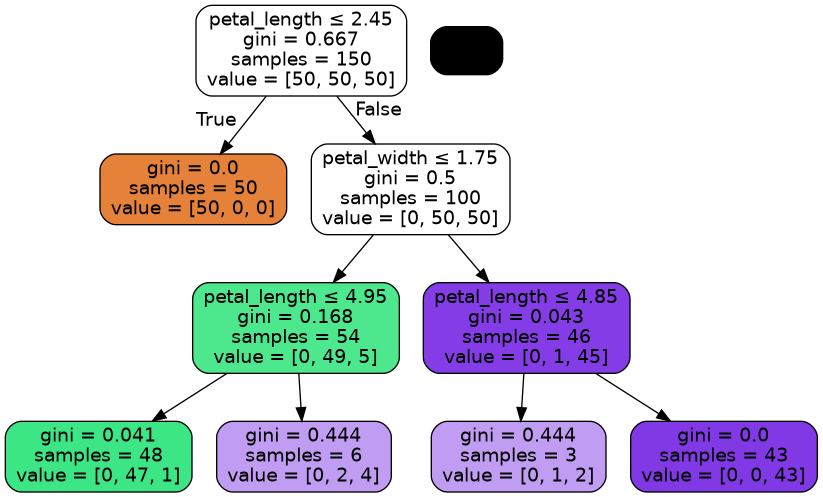

In [18]:
import os
os.environ["PATH"]+=os.path.pathsep+r'C:\Program Files\Graphviz\bin'
from io import StringIO
from IPython.display import Image
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier,export_graphviz
import pydotplus
iris=load_iris()
X=iris.data
y=iris.target
clf=DecisionTreeClassifier(max_depth=3,random_state=42)
clf.fit(X,y)
dot_data=StringIO()
export_graphviz(clf,out_file=dot_data,
feature_names=['sepal.length','sepal.width','petal_length','petal_width'],
filled=True,rounded=True,special_characters=True)
graph=pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png("exercise2b.png")
Image(graph.create_png())

In [17]:
SepalLengthCm=4.8
SepalWidthCm=2.9
PetalLengthCm=1.3
PetalWidthCm=0.2
x=[[SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm]]
res=clf.predict(x)
class_mapping={0:'setosa',1:'versicolor',2:'virginica'}
predicted_class=class_mapping[res[0]]
print("The class predicted is -->"+ predicted_class)

The class predicted is -->setosa
